In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shlex
import re
import numpy as np

In [183]:
tmdb_movies_3d = pd.read_csv('./data/TMDB_3D_Movies_Ani.csv')
tmdb_movies_2d = pd.read_csv('./data/TMDB_2D_Movies_Ani.csv')

In [184]:
country_codes = pd.read_csv('./data/country_codes.csv')

In [4]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [5]:
tmdb_movies_2d['profit'] = tmdb_movies_2d.revenue - tmdb_movies_2d.budget

In [6]:
tmdb_movies_2d[(tmdb_movies_2d.budget != 0) & (tmdb_movies_2d.revenue != 0)].sort_values(by='profit', ascending=False)

,title,id,overview,release_date,runtime,budget,revenue,origin_country,original_language,vote_average,...,release_year,release_month,release_weekday,release_weekday_num,profit,bayesian_rating,rev_bud_ratio,budget_in_2025_dollars,revenue_in_2025_dollars,profit_in_2025_dollars
14,The Lion King,8587,"Young lion prince Simba, eager to one day beco...",1994-06-15,89,45000000,763455561,US,en,8.25,...,1994.00,6.00,Wednesday,2.00,718455561,8.25,16.97,97757836.97,1658528094.82,1560770257.84
32,Demon Slayer: Kimetsu no Yaiba Infinity Castle,1311031,The Demon Slayer Corps are drawn into the Infi...,2025-07-18,156,20000000,733030221,JP,ja,7.68,...,2025.00,7.00,Friday,4.00,713030221,6.11,36.65,20000000.00,733030221.00,713030221.00
59,Demon Slayer -Kimetsu no Yaiba- The Movie: Mug...,635302,"Tanjiro Kamado, joined with Inosuke Hashibira,...",2020-10-16,117,15700000,523542183,JP,ja,8.20,...,2020.00,10.00,Friday,4.00,507842183,6.54,33.35,19533369.74,651372167.93,631838798.19
55,Aladdin,812,"In the boorish city of Agrabah, kind-hearted s...",1992-11-25,91,28000000,504050219,US,en,7.65,...,1992.00,11.00,Wednesday,2.00,476050219,7.03,18.00,64255351.12,1156711564.34,1092456213.23
183,The Simpsons Movie,35,After Homer accidentally pollutes the town's w...,2007-07-25,87,75000000,527068851,US,en,7.02,...,2007.00,7.00,Wednesday,2.00,452068851,6.47,7.03,116475245.94,818539653.97,702064408.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,The Thief and the Cobbler,26672,Princess Yum Yum falls in love with Tack and s...,1993-09-23,72,28000000,669276,GB,en,7.10,...,1993.00,9.00,Thursday,3.00,-27330724,6.05,0.02,62413129.63,1491843.21,-60921286.42
281,Cats Don't Dance,24662,An ambitious singing and dancing cat in 1939 H...,1997-03-26,75,32000000,3600000,US,en,7.20,...,1997.00,3.00,Wednesday,2.00,-28400000,6.06,0.11,64193399.41,7221757.43,-56971641.98
322,Treasure Planet,9016,When space galleon cabin boy Jim Hawkins disco...,2002-11-26,96,140000000,109578115,US,en,7.56,...,2002.00,11.00,Tuesday,1.00,-30421885,6.40,0.78,250621172.59,196161397.66,-54459774.94
493,Titan A.E.,7450,A young man finds out that he holds the key to...,2000-06-16,95,75000000,36754634,US,en,6.61,...,2000.00,6.00,Friday,4.00,-38245366,6.08,0.49,140245406.36,68728914.41,-71516491.95


In [7]:
genres_2d = []
for g in tmdb_movies_2d['genres_list'].str.split(','):
    if type(g) is list:
        genres_2d += g

In [8]:
genres_3d = []
for g in tmdb_movies_3d['genres_list'].str.split(','):
    if type(g) is list:
        genres_3d += g

In [9]:
genres_2d = [g.strip() for g in genres_2d]
genres_3d = [g.strip() for g in genres_3d]

In [10]:
pd.Series(genres_2d).value_counts()

Animation          3041
Comedy              910
Fantasy             860
Action              842
Adventure           799
Science Fiction     771
Family              708
Drama               599
Romance             263
TV Movie            179
Mystery             164
Music               154
Crime               141
Horror              123
Thriller             79
War                  71
History              56
Documentary          35
Western              14
Name: count, dtype: int64

In [11]:
pd.Series(genres_3d).value_counts()

Animation          1852
Family              815
Comedy              680
Adventure           547
Fantasy             424
Science Fiction     285
Action              225
Drama               129
Music                98
Horror               64
Romance              39
Mystery              29
Thriller             27
Documentary          25
TV Movie             22
Crime                18
War                  15
History              14
Western               4
Name: count, dtype: int64

In [12]:
tmdb_movies_2d['release_weekday'].value_counts()

release_weekday
Saturday     940
Friday       814
Wednesday    313
Thursday     293
Tuesday      275
Sunday       197
Monday       191
Name: count, dtype: int64

In [13]:
tmdb_movies_3d['release_weekday'].value_counts()

release_weekday
Friday       407
Thursday     402
Wednesday    265
Tuesday      261
Saturday     196
Monday       158
Sunday       117
Name: count, dtype: int64

In [14]:
tmdb_movies_2d.groupby('release_year')['release_weekday'].agg(pd.Series.mode).tail(50)

release_year
1978.00              Saturday
1979.00              Saturday
1980.00               Tuesday
1981.00              Saturday
1982.00              Saturday
1983.00              Saturday
1984.00                Sunday
1985.00              Saturday
1986.00              Saturday
1987.00              Saturday
1988.00              Saturday
1989.00              Saturday
1990.00    [Friday, Saturday]
1991.00              Saturday
1992.00              Saturday
1993.00              Saturday
1994.00              Saturday
1995.00              Saturday
1996.00                Friday
1997.00              Saturday
1998.00              Saturday
1999.00              Saturday
2000.00              Saturday
2001.00              Saturday
2002.00              Saturday
2003.00                Friday
2004.00              Saturday
2005.00    [Friday, Saturday]
2006.00              Saturday
2007.00              Saturday
2008.00              Saturday
2009.00              Saturday
2010.00              Saturd

In [15]:
tmdb_movies_3d.groupby('release_year')['release_weekday'].agg(pd.Series.mode).tail(50)

release_year
1979.00                          Monday
1981.00                        Thursday
1982.00                          Friday
1983.00                          Monday
1984.00    [Monday, Tuesday, Wednesday]
1985.00                         Tuesday
1986.00                          Monday
1987.00                        Thursday
1988.00                          Friday
1989.00                          Sunday
1990.00                          Monday
1991.00                         Tuesday
1992.00                       Wednesday
1993.00                          Friday
1994.00                        Saturday
1995.00                          Sunday
1996.00                          Monday
1997.00                       Wednesday
1998.00                        Thursday
1999.00                          Friday
2000.00                        Saturday
2001.00                          Monday
2002.00               [Friday, Tuesday]
2003.00                       Wednesday
2004.00             [Thursd

In [16]:
tmdb_movies_3d.sort_values(by='release_year').head(10)

,title,id,overview,release_date,runtime,budget,revenue,origin_country,original_language,vote_average,...,release_year,release_month,release_weekday,release_weekday_num,profit,bayesian_rating,rev_bud_ratio,budget_in_2025_dollars,revenue_in_2025_dollars,profit_in_2025_dollars
1324,High Voltage,882816,High Voltage is constructed from footage James...,1959-01-01,3,0,0,US,en,5.00,...,1959.00,1.00,Thursday,3.00,0,4.67,NaN,0.00,0.00,0.00
771,Lapis,145619,James Whitney’s Lapis (1966) is a classic work...,1966-08-11,10,0,0,US,en,5.90,...,1966.00,8.00,Thursday,3.00,0,4.67,NaN,0.00,0.00,0.00
1335,The Art of Fugue,872064,Japan's first computer generated animation,1967-11-01,3,0,0,JP,ja,0.00,...,1967.00,11.00,Wednesday,2.00,0,4.67,NaN,0.00,0.00,0.00
1242,Hummingbird,515211,Hummingbird is one of the earliest computer-an...,1967-01-01,3,0,0,US,en,0.00,...,1967.00,1.00,Sunday,6.00,0,4.67,NaN,0.00,0.00,0.00
858,Permutations,93507,An experimental short film by John Whitney Sr....,1968-12-21,8,0,0,US,en,6.00,...,1968.00,12.00,Saturday,5.00,0,4.67,NaN,0.00,0.00,0.00
1158,The Flexipede,681383,A two-minute computer animation of a fantastic...,1968-08-02,2,0,0,GB,en,4.50,...,1968.00,8.00,Friday,4.00,0,4.67,NaN,0.00,0.00,0.00
1032,The Apteryx and the Easter Bunny,1310313,First ever color 2D computer animation. Moveme...,1970-01-01,1,0,0,US,en,0.00,...,1970.00,1.00,Thursday,3.00,0,4.67,NaN,0.00,0.00,0.00
1450,Metadata,372415,This short experimental film from Peter Foldès...,1971-01-01,9,0,0,NaN,xx,8.00,...,1971.00,1.00,Friday,4.00,0,4.67,NaN,0.00,0.00,0.00
1354,Matrix,411948,A piece of abstract cinema by John Whitney. A ...,1971-05-18,6,0,0,US,en,7.30,...,1971.00,5.00,Tuesday,1.00,0,4.67,NaN,0.00,0.00,0.00
1375,Thermogenesis,560396,"""A film version of a videotape. In it my drawi...",1972-01-01,12,0,0,US,en,0.00,...,1972.00,1.00,Saturday,5.00,0,4.67,NaN,0.00,0.00,0.00


In [17]:
countries_2d = []
for c in tmdb_movies_2d['production_countries_list'].str.split(','):
    if type(c) is list:
        countries_2d += c

In [18]:
countries_3d = []
for c in tmdb_movies_3d['production_countries_list'].str.split(','):
    if type(c) is list:
        countries_3d += c

In [19]:
countries_2d = [c.strip() for c in countries_2d]
countries_3d = [c.strip() for c in countries_3d]

In [20]:
country_counts_2d = pd.Series(countries_2d).value_counts().reset_index()
country_counts_3d = pd.Series(countries_3d).value_counts().reset_index()

In [21]:
country_counts_2d = pd.merge(country_counts_2d, country_codes, left_on='index', right_on='alpha-2', how='left')[['name', 'alpha-2', 'count']]

In [22]:
country_counts_3d = pd.merge(country_counts_3d, country_codes, left_on='index', right_on='alpha-2', how='left')[['name', 'alpha-2', 'count']]

In [23]:
country_counts_2d.head(10)

,name,alpha-2,count
0,Japan,JP,1747
1,United States of America,US,878
2,France,FR,106
3,Canada,CA,103
4,United Kingdom of Great Britain and Northern I...,GB,70
5,Belgium,BE,44
6,NaN,NaN,44
7,Germany,DE,35
8,"Korea, Republic of",KR,28
9,Australia,AU,21


In [24]:
country_counts_3d.head(10)

,name,alpha-2,count
0,United States of America,US,882
1,France,FR,249
2,Canada,CA,140
3,Japan,JP,136
4,China,CN,105
5,United Kingdom of Great Britain and Northern I...,GB,104
6,Germany,DE,57
7,Spain,ES,44
8,"Korea, Republic of",KR,37
9,Belgium,BE,36


In [25]:
companies_2d = []
for i, row in tmdb_movies_2d.iterrows():
    if type(row['production_companies_list']) is str:
        companies_2d += re.findall(r"\'(.*?)\',?", row['production_companies_list'])

In [26]:
companies_3d = []
for i, row in tmdb_movies_3d.iterrows():
    if type(row['production_companies_list']) is str:
        companies_3d += re.findall(r"\'(.*?)\',?", row['production_companies_list'])

In [27]:
pd.Series(companies_2d).value_counts().head(10)

Toei Animation             190
TOHO                       172
SUNRISE                    121
Production I.G             115
Aniplex                    101
Walt Disney Productions     98
Warner Bros. Animation      97
Madhouse                    96
Shogakukan                  95
Bandai Visual               83
Name: count, dtype: int64

In [28]:
pd.Series(companies_3d).value_counts().head(10)

ESMA                             127
Pixar                             79
DreamWorks Animation              77
Mattel                            50
Illumination                      45
Universal Pictures                36
Walt Disney Pictures              32
Sony Pictures Animation           31
Walt Disney Animation Studios     30
Columbia Pictures                 29
Name: count, dtype: int64

In [29]:
directors_2d = []
for d in tmdb_movies_2d['director'].str.split(','):
    if type(d) is list:
        directors_2d += d

In [30]:
directors_3d = []
for d in tmdb_movies_3d['director'].str.split(','):
    if type(d) is list:
        directors_3d += d

In [31]:
directors_2d = [d.strip() for d in directors_2d]
directors_3d = [d.strip() for d in directors_3d]

In [32]:
pd.Series(directors_2d).value_counts().head(10)

Bill Plympton        42
Kunihiko Yuyama      34
Dave Fleischer       26
Hideaki Anno         26
Chuck Jones          25
Tsutomu Shibayama    23
Yoshiyuki Tomino     21
Koji Yamamura        21
Wilfred Jackson      19
Phil Roman           19
Name: count, dtype: int64

In [33]:
pd.Series(directors_3d).value_counts().head(10)

Mike Nawrocki       15
John Lasseter       14
Kyle Balda          11
Phil Vischer        10
William Lau         10
Ezekiel Norton       9
Hiroyuki Seshita     9
Conrad Helten        9
Richard Rich         9
Shinji Aramaki       9
Name: count, dtype: int64

In [34]:
tmdb_movies_2d.loc[tmdb_movies_2d.runtime >= 70, 'release_weekday'].value_counts()

release_weekday
Saturday     560
Friday       463
Wednesday    134
Tuesday      123
Thursday     121
Sunday        69
Monday        52
Name: count, dtype: int64

In [35]:
tmdb_movies_2d.loc[tmdb_movies_2d.runtime >= 70].groupby('release_year')['release_weekday'].agg(pd.Series.mode).tail(30)

release_year
1997.00              Saturday
1998.00              Saturday
1999.00              Saturday
2000.00    [Friday, Saturday]
2001.00              Saturday
2002.00    [Friday, Saturday]
2003.00              Saturday
2004.00              Saturday
2005.00              Saturday
2006.00              Saturday
2007.00              Saturday
2008.00              Saturday
2009.00              Saturday
2010.00              Saturday
2011.00              Saturday
2012.00              Saturday
2013.00              Saturday
2014.00              Saturday
2015.00              Saturday
2016.00              Saturday
2017.00              Saturday
2018.00    [Friday, Saturday]
2019.00                Friday
2020.00                Friday
2021.00                Friday
2022.00                Friday
2023.00                Friday
2024.00                Friday
2025.00                Friday
2026.00                Friday
Name: release_weekday, dtype: object

In [36]:
tmdb_movies_3d.loc[tmdb_movies_3d.runtime >= 70, 'release_weekday'].value_counts()

release_weekday
Friday       215
Thursday     200
Wednesday    128
Tuesday       75
Saturday      74
Monday        44
Sunday        29
Name: count, dtype: int64

In [37]:
tmdb_movies_3d.loc[tmdb_movies_3d.runtime >= 70].groupby('release_year')['release_weekday'].agg(pd.Series.mode).tail(30)

release_year
1998.00            [Friday, Saturday, Sunday, Wednesday]
1999.00                               [Saturday, Sunday]
2000.00    [Friday, Saturday, Sunday, Thursday, Tuesday]
2001.00                                           Friday
2002.00                                           Friday
2003.00                                           Friday
2004.00                                        Wednesday
2005.00                                          Tuesday
2006.00                                           Friday
2007.00                                           Friday
2008.00                                           Friday
2009.00                                         Thursday
2010.00                                         Thursday
2011.00                                         Thursday
2012.00                                           Friday
2013.00                            [Thursday, Wednesday]
2014.00                                           Friday
2015.00           

In [38]:
cast_2d = pd.read_csv('./data/2D_Movies_Cast.csv')

In [39]:
cast_2d.name.value_counts().head(10)

name
Koichi Yamadera       137
Frank Welker          134
Megumi Hayashibara    125
Kappei Yamaguchi       99
Ikue Otani             94
Shin-ichiro Miki       93
Akio Otsuka            92
Miyuki Sawashiro       90
Kazuhiko Inoue         87
Kenichi Ogata          87
Name: count, dtype: int64

In [40]:
cast_3d = pd.read_csv('./data/3D_Movies_Cast.csv')

In [41]:
cast_3d.name.value_counts().head(10)

name
Frank Welker        51
Fred Tatasciore     46
Laraine Newman      38
Jess Harnell        38
Grey DeLisle        37
Tara Strong         37
Carlos Alazraqui    37
Scott Menville      36
Kari Wahlgren       34
Conrad Vernon       32
Name: count, dtype: int64

In [42]:
(cast_2d.name.value_counts() + cast_3d.name.value_counts()).sort_values(ascending=False).head(10)

name
Frank Welker         185.00
Koichi Yamadera      158.00
Megumi Hayashibara   134.00
Kappei Yamaguchi     101.00
Akio Otsuka          100.00
Miyuki Sawashiro      96.00
Ikue Otani            96.00
Shin-ichiro Miki      96.00
Jeff Bennett          92.00
Takahiro Sakurai      89.00
Name: count, dtype: float64

In [43]:
cast_2d.groupby('name')['popularity'].max().sort_values(ascending=False).head(10)

name
Pierce Brosnan       13.40
Alexandra Daddario   12.82
Tom Hanks            12.46
Keanu Reeves         11.41
Morena Baccarin      10.52
Matt Damon            9.83
Vin Diesel            9.53
Minami Hamabe         9.32
Brad Pitt             9.26
Jensen Ackles         8.89
Name: popularity, dtype: float64

In [44]:
cast_3d.groupby('name')['popularity'].max().sort_values(ascending=False).head(10)

name
Valorie Curry      30.62
Anne Hathaway      24.24
Taron Egerton      21.70
Charlize Theron    21.66
Jamie Lee Curtis   20.10
Tom Cruise         18.44
Mila Kunis         17.29
Jason Statham      16.99
Elle Fanning       16.32
Tom Hanks          16.20
Name: popularity, dtype: float64

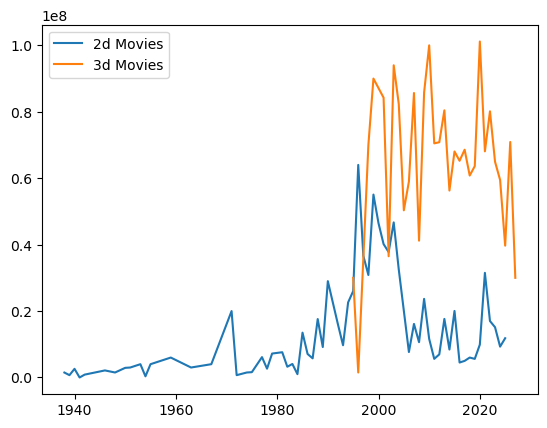

In [45]:
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.budget != 0) & (tmdb_movies_2d.runtime >= 70)].groupby('release_year')['budget'].mean(), label='2d Movies')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.budget != 0) & (tmdb_movies_3d.runtime >= 70)].groupby('release_year')['budget'].mean(), label='3d Movies')
plt.legend()
plt.show()

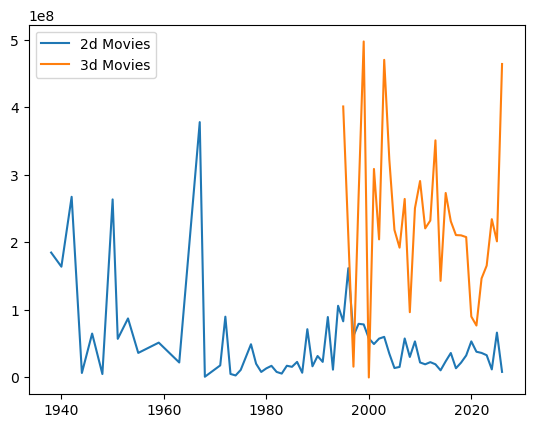

In [46]:
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.revenue != 0) & (tmdb_movies_2d.runtime >= 70)].groupby('release_year')['revenue'].mean(), label='2d Movies')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.revenue != 0) & (tmdb_movies_3d.runtime >= 70)].groupby('release_year')['revenue'].mean(), label='3d Movies')
plt.legend()
plt.show()

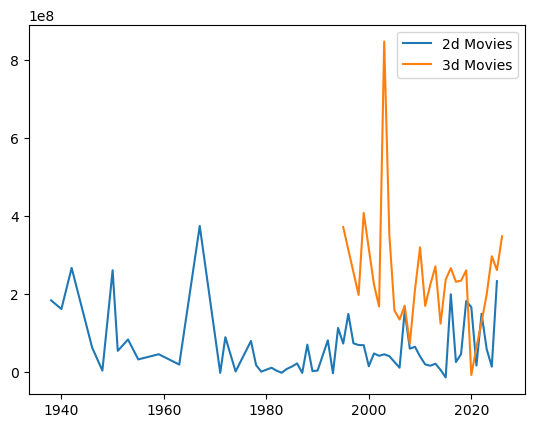

In [47]:
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.budget != 0) & (tmdb_movies_2d.revenue != 0) & (tmdb_movies_2d.runtime >= 70)].groupby('release_year')['profit'].mean(), label='2d Movies')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.budget != 0) & (tmdb_movies_3d.revenue != 0) & (tmdb_movies_3d.runtime >= 70)].groupby('release_year')['profit'].mean(), label='3d Movies')
plt.legend()
plt.show()

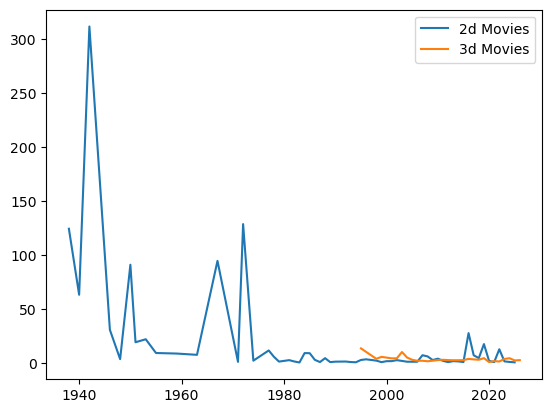

In [48]:
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.budget != 0) & (tmdb_movies_2d.revenue != 0) & (tmdb_movies_2d.runtime >= 70)].groupby('release_year')['rev_bud_ratio'].median(), label='2d Movies')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.budget != 0) & (tmdb_movies_3d.revenue != 0) & (tmdb_movies_3d.runtime >= 70)].groupby('release_year')['rev_bud_ratio'].median(), label='3d Movies')
plt.legend()
plt.show()

In [125]:
# avg_rating_2d = tmdb_movies_2d.vote_average.mean()

In [126]:
# max_vote_count_2d = tmdb_movies_2d.vote_count.max()

In [127]:
# tmdb_movies_2d['bayesian_rating'] = ((tmdb_movies_2d.vote_count / max_vote_count_2d) * tmdb_movies_2d.vote_average) + ((1 - (tmdb_movies_2d.vote_count / max_vote_count_2d)) * avg_rating_2d)

In [128]:
tmdb_movies_2d.sort_values(by='bayesian_rating', ascending=False)

,title,id,overview,release_date,runtime,budget,revenue,origin_country,original_language,vote_average,...,release_year,release_month,release_weekday,release_weekday_num,profit,bayesian_rating,rev_bud_ratio,budget_in_2025_dollars,revenue_in_2025_dollars,profit_in_2025_dollars
0,Spirited Away,129,"A young girl, Chihiro, becomes trapped in a st...",2001-07-20,125,19000000,274925095,JP,ja,8.50,...,2001.00,7.00,Friday,4.00,255925095,8.32,14.47,34552328.35,499963271.31,465410942.96
14,The Lion King,8587,"Young lion prince Simba, eager to one day beco...",1994-06-15,89,45000000,763455561,US,en,8.25,...,1994.00,6.00,Wednesday,2.00,718455561,8.25,16.97,97757836.97,1658528094.82,1560770257.84
10,Your Name.,372058,High schoolers Mitsuha and Taki are complete s...,2016-08-26,106,7500000,405320132,JP,ja,8.48,...,2016.00,8.00,Friday,4.00,397820132,7.59,54.04,10062307.43,543794103.68,533731796.25
36,Howl's Moving Castle,4935,"Sophie, a young milliner, is turned into an el...",2004-09-09,119,24000000,236049757,JP,ja,8.39,...,2004.00,9.00,Thursday,3.00,212049757,7.36,9.84,40914583.28,402411560.05,361496976.77
9,Princess Mononoke,128,"Ashitaka, a prince of the disappearing Emishi ...",1997-07-12,134,23500000,176506186,JP,ja,8.32,...,1997.00,7.00,Saturday,5.00,153006186,7.08,7.51,47142027.69,354079128.03,306937100.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1223,The Jungle Book 2,14873,Mowgli has been living in the man-village with...,2003-02-07,72,20000000,135700000,US,en,5.90,...,2003.00,2.00,Friday,4.00,115700000,6.04,6.79,35008302.93,237531335.39,202523032.46
1222,Eight Crazy Nights,13376,"Davey Stone, a 33-year old party animal, finds...",2002-11-27,76,3400000,23833131,US,en,5.21,...,2002.00,11.00,Wednesday,2.00,20433131,6.03,7.01,6086514.19,42664908.84,36578394.65
1409,Cool World,14239,"While incarcerated for murder, cartoonist Jack...",1992-07-10,102,30000000,14110589,US,en,5.63,...,1992.00,7.00,Friday,4.00,-15889411,6.03,0.47,68845019.05,32381458.95,-36463560.10
1320,The Hunchback of Notre Dame II,12448,"Now that Frollo is gone, Quasimodo rings the b...",2002-02-06,68,0,0,US,en,5.38,...,2002.00,2.00,Wednesday,2.00,0,6.02,NaN,0.00,0.00,0.00


In [129]:
# avg_rating_3d = tmdb_movies_3d.vote_average.mean()
# max_vote_count_3d = tmdb_movies_3d.vote_count.max()

In [130]:
# tmdb_movies_3d['bayesian_rating'] = ((tmdb_movies_3d.vote_count / max_vote_count_3d) * tmdb_movies_3d.vote_average) + ((1 - (tmdb_movies_3d.vote_count / max_vote_count_3d)) * avg_rating_3d)

In [55]:
tmdb_movies_3d.sort_values(by='bayesian_rating', ascending=False)

,title,id,overview,release_date,runtime,budget,revenue,origin_country,original_language,vote_average,...,release_year,release_month,release_weekday,release_weekday_num,profit,bayesian_rating,rev_bud_ratio,budget_in_2025_dollars,revenue_in_2025_dollars,profit_in_2025_dollars
8,Inside Out,150540,"When 11-year-old Riley moves to a new city, he...",2015-06-17,95,175000000,857611174,US,en,7.91,...,2015.00,6.00,Wednesday,2.00,682611174,7.91,4.90,237749209.02,1165122161.53,927372952.51
5,Coco,354912,Despite his family’s baffling generations-old ...,2017-10-27,105,175000000,814641172,US,en,8.20,...,2017.00,10.00,Friday,4.00,639641172,7.82,4.66,229890258.09,1070160395.89,840270137.80
6,Up,14160,Carl Fredricksen spent his entire life dreamin...,2009-05-28,96,175000000,735103954,US,en,7.96,...,2009.00,5.00,Thursday,3.00,560103954,7.71,4.20,262661472.26,1103334210.43,840672738.16
9,Toy Story,862,"Led by Woody, Andy's toys live happily in his ...",1995-11-22,81,30000000,401157969,US,en,7.97,...,1995.00,11.00,Wednesday,2.00,371157969,7.46,13.37,63393439.29,847692778.41,784299339.12
7,Finding Nemo,12,"Nemo, an adventurous young clownfish, is unexp...",2003-05-30,100,94000000,940335536,US,en,7.82,...,2003.00,5.00,Friday,4.00,846335536,7.43,10.00,164539023.78,1645977565.05,1481438541.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,Plan Bee,85405,Bing loves being a bee in DC. He loves the fre...,2008-01-21,42,0,0,US,en,1.30,...,2008.00,1.00,Monday,0.00,0,4.67,NaN,0.00,0.00,0.00
810,Pinocchio: A True Story,597840,Young Pinocchio runs away from his genius crea...,2021-12-23,94,6100000,822000,RU,ru,2.90,...,2021.00,12.00,Thursday,3.00,-5278000,4.67,0.13,7248857.35,976813.24,-6272044.11
960,A Fox's Tale,31250,"The film is about Little Vuk, the son of the l...",2008-04-17,85,5000000,112794,"HU, GB",hu,1.80,...,2008.00,4.00,Thursday,3.00,-4887206,4.67,0.02,7477931.12,168693.15,-7309237.97
863,The Rapsittie Street Kids: Believe in Santa,413817,Ricky wants to give his crush Nicole a Christm...,2002-11-25,42,650000,0,US,en,2.21,...,2002.00,11.00,Monday,0.00,-650000,4.67,NaN,1163598.30,0.00,-1163598.30


In [56]:
tmdb_movies_2d[(tmdb_movies_2d.rev_bud_ratio >= 2.5) & (tmdb_movies_2d.runtime > 70)].sort_values(by='bayesian_rating')

,title,id,overview,release_date,runtime,budget,revenue,origin_country,original_language,vote_average,...,release_year,release_month,release_weekday,release_weekday_num,profit,bayesian_rating,rev_bud_ratio,budget_in_2025_dollars,revenue_in_2025_dollars,profit_in_2025_dollars
1222,Eight Crazy Nights,13376,"Davey Stone, a 33-year old party animal, finds...",2002-11-27,76,3400000,23833131,US,en,5.21,...,2002.00,11.00,Wednesday,2.00,20433131,6.03,7.01,6086514.19,42664908.84,36578394.65
1223,The Jungle Book 2,14873,Mowgli has been living in the man-village with...,2003-02-07,72,20000000,135700000,US,en,5.90,...,2003.00,2.00,Friday,4.00,115700000,6.04,6.79,35008302.93,237531335.39,202523032.46
893,The Care Bears Movie,11243,The Care Bears team up with a troubled brother...,1985-03-23,76,2000000,34000000,NaN,en,6.05,...,1985.00,3.00,Saturday,5.00,32000000,6.05,17.00,5987049.02,101779833.30,95792784.28
1417,Farewell to Space Battleship Yamato,65665,The Yamato and her crew face the onslaught of ...,1978-07-14,151,3600000,43000000,JP,ja,7.50,...,1978.00,7.00,Friday,4.00,39400000,6.05,11.94,17770246.77,212255725.28,194485478.51
621,Melody Time,13757,In the grand tradition of Disney's great music...,1948-05-27,75,1500000,5120000,US,en,6.10,...,1948.00,5.00,Thursday,3.00,3620000,6.05,3.41,20090336.76,68575016.13,48484679.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9,Princess Mononoke,128,"Ashitaka, a prince of the disappearing Emishi ...",1997-07-12,134,23500000,176506186,JP,ja,8.32,...,1997.00,7.00,Saturday,5.00,153006186,7.08,7.51,47142027.69,354079128.03,306937100.34
36,Howl's Moving Castle,4935,"Sophie, a young milliner, is turned into an el...",2004-09-09,119,24000000,236049757,JP,ja,8.39,...,2004.00,9.00,Thursday,3.00,212049757,7.36,9.84,40914583.28,402411560.05,361496976.77
10,Your Name.,372058,High schoolers Mitsuha and Taki are complete s...,2016-08-26,106,7500000,405320132,JP,ja,8.48,...,2016.00,8.00,Friday,4.00,397820132,7.59,54.04,10062307.43,543794103.68,533731796.25
14,The Lion King,8587,"Young lion prince Simba, eager to one day beco...",1994-06-15,89,45000000,763455561,US,en,8.25,...,1994.00,6.00,Wednesday,2.00,718455561,8.25,16.97,97757836.97,1658528094.82,1560770257.84


In [57]:
disney_2d = tmdb_movies_2d[(~tmdb_movies_2d.production_companies_list.isna()) & (tmdb_movies_2d.production_companies_list.str.contains('Disney'))]

In [58]:
disney_3d = tmdb_movies_3d[(~tmdb_movies_3d.production_companies_list.isna()) & (tmdb_movies_3d.production_companies_list.str.contains('Disney|Pixar', regex=True))]

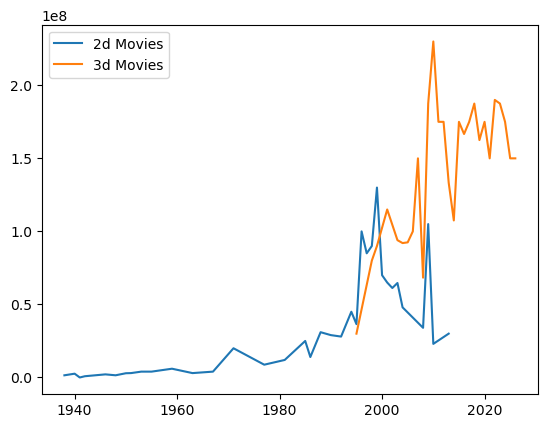

In [59]:
plt.plot(disney_2d[(disney_2d.budget != 0) & (disney_2d.runtime >= 70)].groupby('release_year')['budget'].mean(), label='2d Movies')
plt.plot(disney_3d[(disney_3d.budget != 0) & (disney_3d.runtime >= 70)].groupby('release_year')['budget'].mean(), label='3d Movies')
plt.legend()
plt.show()

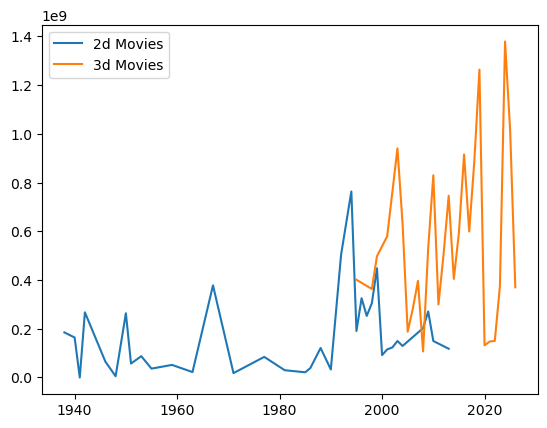

In [60]:
plt.plot(disney_2d[(disney_2d.budget != 0) & (disney_2d.runtime >= 70)].groupby('release_year')['revenue'].mean(), label='2d Movies')
plt.plot(disney_3d[(disney_3d.budget != 0) & (disney_3d.runtime >= 70)].groupby('release_year')['revenue'].mean(), label='3d Movies')
plt.legend()
plt.show()

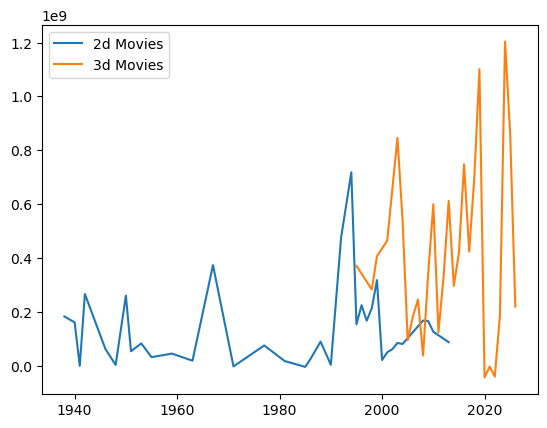

In [61]:
plt.plot(disney_2d[(disney_2d.budget != 0) & (disney_2d.runtime >= 70)].groupby('release_year')['profit'].mean(), label='2d Movies')
plt.plot(disney_3d[(disney_3d.budget != 0) & (disney_3d.runtime >= 70)].groupby('release_year')['profit'].mean(), label='3d Movies')
plt.legend()
plt.show()

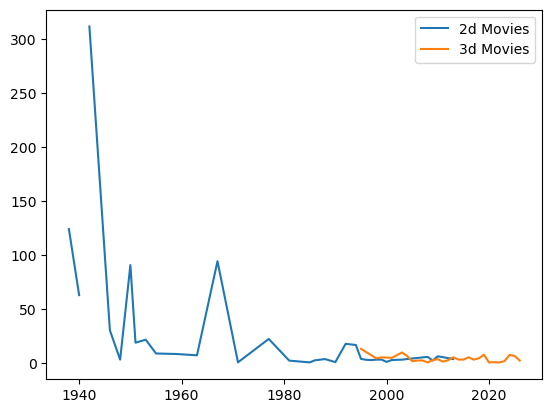

In [62]:
plt.plot(disney_2d[(disney_2d.budget != 0) & (disney_2d.runtime >= 70) ].groupby('release_year')['rev_bud_ratio'].mean(), label='2d Movies')
plt.plot(disney_3d[(disney_3d.budget != 0) & (disney_3d.runtime >= 70)].groupby('release_year')['rev_bud_ratio'].mean(), label='3d Movies')
plt.legend()
plt.show()

In [63]:
tmdb_movies_2d.sort_values(by='rev_bud_ratio', ascending=False)

,title,id,overview,release_date,runtime,budget,revenue,origin_country,original_language,vote_average,...,release_year,release_month,release_weekday,release_weekday_num,profit,bayesian_rating,rev_bud_ratio,budget_in_2025_dollars,revenue_in_2025_dollars,profit_in_2025_dollars
145,Bambi,3170,Bambi's tale unfolds from season to season as ...,1942-08-14,70,858000,267447150,US,en,7.00,...,1942.00,8.00,Friday,4.00,266589150,6.34,311.71,16915038.53,5272586069.08,5255671030.55
276,Demon Slayer: Kimetsu no Yaiba -To the Hashira...,1216221,Tanjiro undergoes rigorous training with the S...,2024-02-02,103,200000,44354825,JP,ja,6.51,...,2024.00,2.00,Friday,4.00,44154825,6.06,221.77,205400.00,45552405.26,45347005.26
597,Fritz the Cat,12593,"In late 1960s New York City, fed up with monot...",1972-04-14,78,700000,90000000,US,en,6.20,...,1972.00,4.00,Friday,4.00,89300000,6.05,128.57,5390253.10,693032541.33,687642288.23
123,Dragon Ball Super: Broly,503314,Earth is peaceful following the Tournament of ...,2018-12-14,101,1000000,125002821,JP,ja,7.90,...,2018.00,12.00,Friday,4.00,124002821,6.34,125.00,1282336.48,160295677.59,159013341.11
62,Snow White and the Seven Dwarfs,408,"A beautiful girl, Snow White, takes refuge in ...",1938-01-14,83,1488423,184925486,US,en,7.12,...,1938.00,1.00,Friday,4.00,183437063,6.48,124.24,34011402.40,4225663752.08,4191652349.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035,The Roots of Japanese Anime Until the End of W...,690199,A rare glimpse of early Japanese sound anime a...,2008-01-01,88,0,0,JP,ja,0.00,...,2008.00,1.00,Tuesday,1.00,0,6.05,NaN,0.00,0.00,0.00
3036,Me...Jane,548663,Patrick McDonnell tells the story of the young...,2015-01-10,9,0,0,US,en,0.00,...,2015.00,1.00,Saturday,5.00,0,6.05,NaN,0.00,0.00,0.00
3037,Horizon Blue,745313,"The latest from Hiroshi Harada, an adaptation ...",2020-04-25,112,0,0,JP,ja,0.00,...,2020.00,4.00,Saturday,5.00,0,6.05,NaN,0.00,0.00,0.00
3038,The Missing Pig,720636,A mysterious pig disappearance brings chaos to...,2018-09-28,4,0,0,GB,en,0.00,...,2018.00,9.00,Friday,4.00,0,6.05,NaN,0.00,0.00,0.00


In [64]:
# cpi = pd.read_csv('cpiai.csv')

In [65]:
# cpi.Date = pd.to_datetime(cpi.Date)

In [66]:
# cpi['Year'] = cpi.Date.dt.year

In [67]:
# cpi

In [68]:
# cpi_year = cpi.groupby('Year')['Index'].mean().reset_index()

In [69]:
# cpi_year.loc[len(cpi_year)] = [2024, 313.537929]

In [70]:
# cpi_year.loc[len(cpi_year)] = [2025, 322.003453]

In [71]:
# cpi_year

In [72]:
# cpi_year['dollar_worth_2025'] = 1

In [73]:
# cpi_2025 = cpi_year[cpi_year.Year == 2025]['Index'][112]

In [74]:
# for i, row in cpi_year.iterrows():
#     dollar_worth = ((cpi_2025 - row['Index']) / row['Index']) + 1
#     cpi_year.loc[i, 'dollar_worth_2025'] = dollar_worth

In [75]:
# cpi_year.to_csv('cpi_year.csv')

In [76]:
# tmdb_movies_2d['budget_in_2025_dollars'] = tmdb_movies_2d.budget

In [77]:
# for i, row in tmdb_movies_2d.iterrows():
#     if (row.release_year >= 1913) & (row.release_year <= 2025):
#         tmdb_movies_2d.loc[i, 'budget_in_2025_dollars'] *= cpi_year.loc[cpi_year.Year == row.release_year, 'dollar_worth_2025'].iloc[0]

In [78]:
# tmdb_movies_2d['revenue_in_2025_dollars'] = tmdb_movies_2d.revenue

In [79]:
# for i, row in tmdb_movies_2d.iterrows():
#     if (row.release_year >= 1913) & (row.release_year <= 2025):
#         tmdb_movies_2d.loc[i, 'revenue_in_2025_dollars'] *= cpi_year.loc[cpi_year.Year == row.release_year, 'dollar_worth_2025'].iloc[0]

In [80]:
# tmdb_movies_2d['profit_in_2025_dollars'] = tmdb_movies_2d['revenue_in_2025_dollars'] - tmdb_movies_2d['budget_in_2025_dollars']

In [81]:
# tmdb_movies_3d['budget_in_2025_dollars'] = tmdb_movies_3d.budget
# for i, row in tmdb_movies_3d.iterrows():
#     if (row.release_year >= 1913) & (row.release_year <= 2025):
#         tmdb_movies_3d.loc[i, 'budget_in_2025_dollars'] *= cpi_year.loc[cpi_year.Year == row.release_year, 'dollar_worth_2025'].iloc[0]

In [82]:
# tmdb_movies_3d['revenue_in_2025_dollars'] = tmdb_movies_3d.revenue
# for i, row in tmdb_movies_3d.iterrows():
#     if (row.release_year >= 1913) & (row.release_year <= 2025):
#         tmdb_movies_3d.loc[i, 'revenue_in_2025_dollars'] *= cpi_year.loc[cpi_year.Year == row.release_year, 'dollar_worth_2025'].iloc[0]

In [83]:
# tmdb_movies_3d['profit_in_2025_dollars'] = tmdb_movies_3d['revenue_in_2025_dollars'] - tmdb_movies_3d['budget_in_2025_dollars']

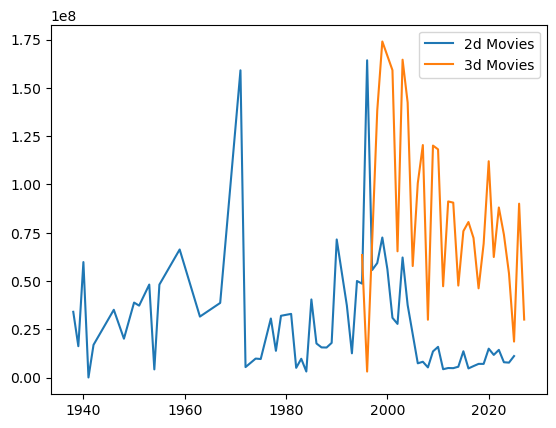

In [84]:
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.budget_in_2025_dollars != 0) & (tmdb_movies_2d.runtime >= 70)].groupby('release_year')['budget_in_2025_dollars'].median(), label='2d Movies')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.budget_in_2025_dollars != 0) & (tmdb_movies_3d.runtime >= 70)].groupby('release_year')['budget_in_2025_dollars'].median(), label='3d Movies')
plt.legend()
plt.show()

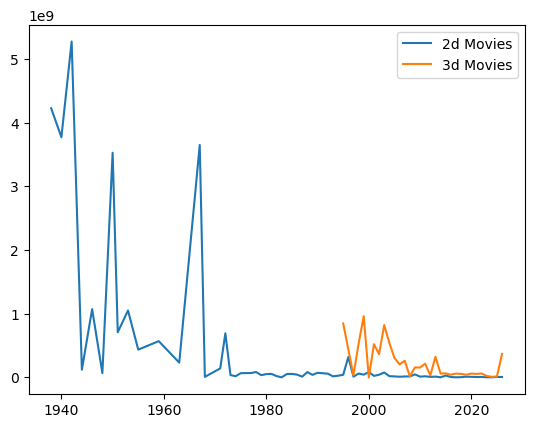

In [85]:
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.revenue_in_2025_dollars != 0) & (tmdb_movies_2d.runtime >= 70)].groupby('release_year')['revenue_in_2025_dollars'].median(), label='2d Movies')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.revenue_in_2025_dollars != 0) & (tmdb_movies_3d.runtime >= 70)].groupby('release_year')['revenue_in_2025_dollars'].median(), label='3d Movies')
plt.legend()
plt.show()

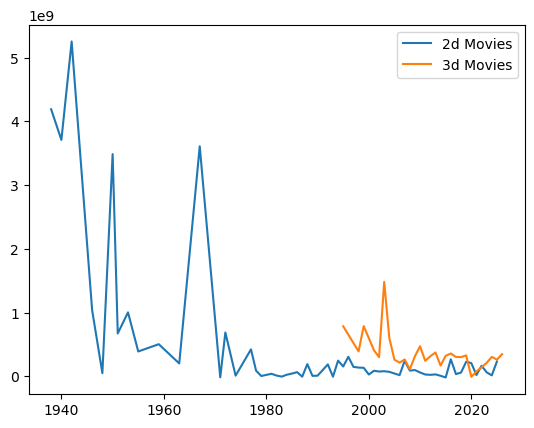

In [190]:
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.budget_in_2025_dollars != 0) & (tmdb_movies_2d.revenue_in_2025_dollars != 0) & (tmdb_movies_2d.runtime >= 70)].groupby('release_year')['profit_in_2025_dollars'].mean(), label='2d Movies')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.budget_in_2025_dollars != 0) & (tmdb_movies_3d.revenue_in_2025_dollars != 0) & (tmdb_movies_3d.runtime >= 70)].groupby('release_year')['profit_in_2025_dollars'].mean(), label='3d Movies')
plt.legend()
plt.show()

In [191]:
tmdb_movies_3d[(tmdb_movies_3d.budget_in_2025_dollars != 0) & (tmdb_movies_3d.revenue_in_2025_dollars != 0) & (tmdb_movies_3d.runtime >= 70)].groupby('release_year')['profit_in_2025_dollars'].mean()

release_year
1995.00    784299339.12
1998.00    390154128.55
1999.00    787490840.49
2001.00    408147551.49
2002.00    300631165.92
2003.00   1481438541.27
2004.00    600793508.79
2005.00    260239914.21
2006.00    214744178.53
2007.00    263763259.29
2008.00    108997602.82
2009.00    315140537.49
2010.00    471336241.31
2011.00    242457530.27
2012.00    313999990.04
2013.00    374024637.02
2014.00    168358959.56
2015.00    321260716.32
2016.00    357147481.83
2017.00    303655387.42
2018.00    299965212.90
2019.00    327802056.48
2020.00     -9294295.83
2021.00     75267061.09
2022.00    141393617.90
2023.00    209855182.73
2024.00    304516127.32
2025.00    260946947.56
2026.00    347379911.00
Name: profit_in_2025_dollars, dtype: float64

In [87]:
tmdb_movies_2d.to_csv('TMDB_2D_Movies_Ani.csv', index=False)
tmdb_movies_3d.to_csv('TMDB_3D_Movies_Ani.csv', index=False)

In [88]:
tmdb_movies_3d.sort_values(by='bayesian_rating', ascending=False)

,title,id,overview,release_date,runtime,budget,revenue,origin_country,original_language,vote_average,...,release_year,release_month,release_weekday,release_weekday_num,profit,bayesian_rating,rev_bud_ratio,budget_in_2025_dollars,revenue_in_2025_dollars,profit_in_2025_dollars
8,Inside Out,150540,"When 11-year-old Riley moves to a new city, he...",2015-06-17,95,175000000,857611174,US,en,7.91,...,2015.00,6.00,Wednesday,2.00,682611174,7.91,4.90,237749209.02,1165122161.53,927372952.51
5,Coco,354912,Despite his family’s baffling generations-old ...,2017-10-27,105,175000000,814641172,US,en,8.20,...,2017.00,10.00,Friday,4.00,639641172,7.82,4.66,229890258.09,1070160395.89,840270137.80
6,Up,14160,Carl Fredricksen spent his entire life dreamin...,2009-05-28,96,175000000,735103954,US,en,7.96,...,2009.00,5.00,Thursday,3.00,560103954,7.71,4.20,262661472.26,1103334210.43,840672738.16
9,Toy Story,862,"Led by Woody, Andy's toys live happily in his ...",1995-11-22,81,30000000,401157969,US,en,7.97,...,1995.00,11.00,Wednesday,2.00,371157969,7.46,13.37,63393439.29,847692778.41,784299339.12
7,Finding Nemo,12,"Nemo, an adventurous young clownfish, is unexp...",2003-05-30,100,94000000,940335536,US,en,7.82,...,2003.00,5.00,Friday,4.00,846335536,7.43,10.00,164539023.78,1645977565.05,1481438541.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,Plan Bee,85405,Bing loves being a bee in DC. He loves the fre...,2008-01-21,42,0,0,US,en,1.30,...,2008.00,1.00,Monday,0.00,0,4.67,NaN,0.00,0.00,0.00
810,Pinocchio: A True Story,597840,Young Pinocchio runs away from his genius crea...,2021-12-23,94,6100000,822000,RU,ru,2.90,...,2021.00,12.00,Thursday,3.00,-5278000,4.67,0.13,7248857.35,976813.24,-6272044.11
960,A Fox's Tale,31250,"The film is about Little Vuk, the son of the l...",2008-04-17,85,5000000,112794,"HU, GB",hu,1.80,...,2008.00,4.00,Thursday,3.00,-4887206,4.67,0.02,7477931.12,168693.15,-7309237.97
863,The Rapsittie Street Kids: Believe in Santa,413817,Ricky wants to give his crush Nicole a Christm...,2002-11-25,42,650000,0,US,en,2.21,...,2002.00,11.00,Monday,0.00,-650000,4.67,NaN,1163598.30,0.00,-1163598.30


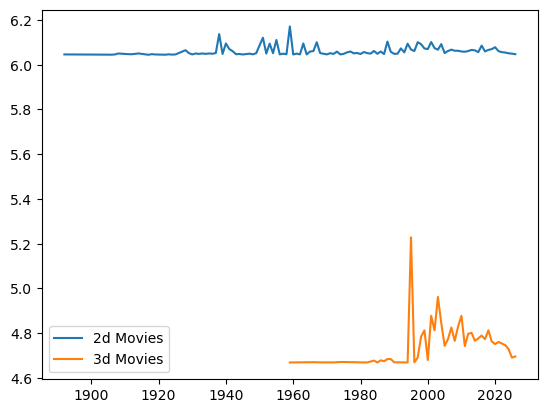

In [89]:
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.vote_count > 0)].groupby('release_year')['bayesian_rating'].mean(), label='2d Movies')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.vote_count > 0)].groupby('release_year')['bayesian_rating'].mean(), label='3d Movies')
plt.legend()
plt.show()

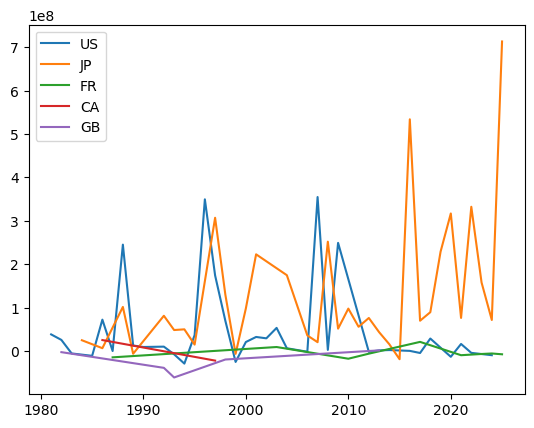

In [90]:
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.budget_in_2025_dollars != 0) & (tmdb_movies_2d.revenue_in_2025_dollars != 0) & (tmdb_movies_2d.runtime >= 70) & (tmdb_movies_2d.origin_country.str.contains('US')) & (tmdb_movies_2d.release_year >= 1980)].groupby('release_year')['profit_in_2025_dollars'].median(), label='US')
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.budget_in_2025_dollars != 0) & (tmdb_movies_2d.revenue_in_2025_dollars != 0) & (tmdb_movies_2d.runtime >= 70) & (tmdb_movies_2d.origin_country.str.contains('JP')) & (tmdb_movies_2d.release_year >= 1980)].groupby('release_year')['profit_in_2025_dollars'].median(), label='JP')
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.budget_in_2025_dollars != 0) & (tmdb_movies_2d.revenue_in_2025_dollars != 0) & (tmdb_movies_2d.runtime >= 70) & (tmdb_movies_2d.origin_country.str.contains('FR')) & (tmdb_movies_2d.release_year >= 1980)].groupby('release_year')['profit_in_2025_dollars'].median(), label='FR')
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.budget_in_2025_dollars != 0) & (tmdb_movies_2d.revenue_in_2025_dollars != 0) & (tmdb_movies_2d.runtime >= 70) & (tmdb_movies_2d.origin_country.str.contains('CA')) & (tmdb_movies_2d.release_year >= 1980)].groupby('release_year')['profit_in_2025_dollars'].median(), label='CA')
plt.plot(tmdb_movies_2d[(tmdb_movies_2d.budget_in_2025_dollars != 0) & (tmdb_movies_2d.revenue_in_2025_dollars != 0) & (tmdb_movies_2d.runtime >= 70) & (tmdb_movies_2d.origin_country.str.contains('GB')) & (tmdb_movies_2d.release_year >= 1980)].groupby('release_year')['profit_in_2025_dollars'].median(), label='GB')
plt.legend()
plt.show()

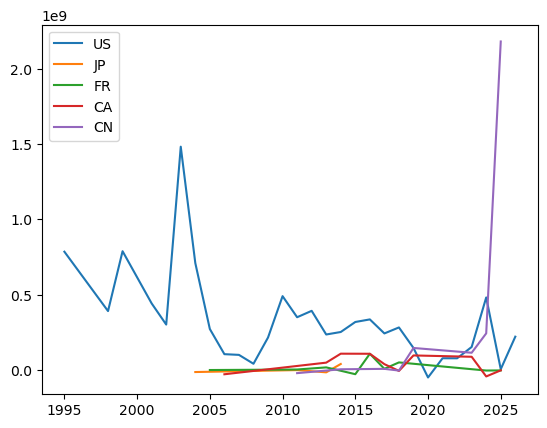

In [91]:
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.budget_in_2025_dollars != 0) & (tmdb_movies_3d.revenue_in_2025_dollars != 0) & (tmdb_movies_3d.runtime >= 70) & (tmdb_movies_3d.origin_country.str.contains('US')) & (tmdb_movies_3d.release_year >= 1980)].groupby('release_year')['profit_in_2025_dollars'].median(), label='US')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.budget_in_2025_dollars != 0) & (tmdb_movies_3d.revenue_in_2025_dollars != 0) & (tmdb_movies_3d.runtime >= 70) & (tmdb_movies_3d.origin_country.str.contains('JP')) & (tmdb_movies_3d.release_year >= 1980)].groupby('release_year')['profit_in_2025_dollars'].median(), label='JP')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.budget_in_2025_dollars != 0) & (tmdb_movies_3d.revenue_in_2025_dollars != 0) & (tmdb_movies_3d.runtime >= 70) & (tmdb_movies_3d.origin_country.str.contains('FR')) & (tmdb_movies_3d.release_year >= 1980)].groupby('release_year')['profit_in_2025_dollars'].median(), label='FR')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.budget_in_2025_dollars != 0) & (tmdb_movies_3d.revenue_in_2025_dollars != 0) & (tmdb_movies_3d.runtime >= 70) & (tmdb_movies_3d.origin_country.str.contains('CA')) & (tmdb_movies_3d.release_year >= 1980)].groupby('release_year')['profit_in_2025_dollars'].median(), label='CA')
plt.plot(tmdb_movies_3d[(tmdb_movies_3d.budget_in_2025_dollars != 0) & (tmdb_movies_3d.revenue_in_2025_dollars != 0) & (tmdb_movies_3d.runtime >= 70) & (tmdb_movies_3d.origin_country.str.contains('CN')) & (tmdb_movies_3d.release_year >= 1980)].groupby('release_year')['profit_in_2025_dollars'].median(), label='CN')
plt.legend()
plt.show()

In [92]:
# prod_co_2d = tmdb_movies_2d.production_companies_list.str.findall(r'(\'.*?\')|(".*?")').explode()

In [93]:
# prod_co_2d = prod_co_2d.reset_index()

In [94]:
# for i, row in prod_co_2d.iterrows():
#     if type(row['production_companies_list']) is tuple:
#         if row['production_companies_list'][1] == '':
#             prod_co_2d.loc[i, 'production_companies_list'] = row['production_companies_list'][0].strip("'")
#         else:
#             prod_co_2d.loc[i, 'production_companies_list'] = row['production_companies_list'][1].strip('"')

In [95]:
# prod_co_2d.columns = ['movie_index', 'production_company']

In [96]:
# prod_co_2d.to_csv('2D_Movies_Prod_Cos.csv', index=False)

In [97]:
# prod_co_3d = tmdb_movies_3d.production_companies_list.str.findall(r'(\'.*?\')|(".*?")').explode()

In [98]:
# prod_co_3d = prod_co_3d.reset_index()

In [99]:
# for i, row in prod_co_3d.iterrows():
#     if type(row['production_companies_list']) is tuple:
#         if row['production_companies_list'][1] == '':
#             prod_co_3d.loc[i, 'production_companies_list'] = row['production_companies_list'][0].strip("'")
#         else:
#             prod_co_3d.loc[i, 'production_companies_list'] = row['production_companies_list'][1].strip('"')

In [100]:
# prod_co_3d.columns = ['movie_index', 'production_company']

In [101]:
# prod_co_3d.to_csv('3D_Movies_Prod_Cos.csv', index=False)

In [102]:
# prod_co_2d = pd.merge(prod_co_2d, tmdb_movies_2d['id'], left_on='movie_index', right_index=True, how='left')

In [103]:
# prod_co_2d.columns = ['movie_index', 'production_company', 'movie_id']

In [104]:
# prod_co_2d.to_csv('2D_Movies_Prod_Cos.csv', index=False)

In [105]:
# prod_co_3d = pd.merge(prod_co_3d, tmdb_movies_3d['id'], left_on='movie_index', right_index=True, how='left')

In [106]:
# prod_co_3d.columns = ['movie_index', 'production_company', 'movie_id']

In [107]:
# prod_co_3d.to_csv('3D_Movies_Prod_Cos.csv', index=False)

In [108]:
prod_co_2d = pd.read_csv('./data/2D_Movies_Prod_Cos.csv')

In [109]:
prod_co_3d = pd.read_csv('./data/3D_Movies_Prod_Cos.csv')

In [110]:
prod_co_3d

,movie_index,production_company,movie_id
0,0,Columbia Pictures,569094
1,0,Sony Pictures Animation,569094
2,0,Lord Miller,569094
3,0,Pascal Pictures,569094
4,0,Arad Productions,569094
...,...,...,...
3773,1846,schnüdlbug,729501
3774,1847,El Señor Studio,438247
3775,1848,NaN,743540
3776,1849,"Animusic, LLC",737029


In [111]:
crew_2d = pd.read_csv('./data/2D_Movies_Crew.csv')

In [112]:
crew_3d = pd.read_csv('./data/3D_Movies_Crew.csv')

In [113]:
cast_2d.gender.value_counts()

gender
2    20034
1    13529
0     2923
3       20
Name: count, dtype: int64

In [114]:
countries_2d = tmdb_movies_2d[tmdb_movies_2d.runtime >= 70].production_countries_list.str.split(',').explode().str.strip().value_counts()

In [115]:
countries_3d = tmdb_movies_3d[tmdb_movies_3d.runtime >= 70].production_countries_list.str.split(',').explode().str.strip().value_counts()

In [116]:
countries_total = pd.concat([countries_2d, countries_3d]).reset_index().groupby('production_countries_list')['count'].sum()

In [117]:
(countries_2d / countries_total).sort_values(ascending=False)

production_countries_list
CI   1.00
BG   1.00
KP   1.00
IL   1.00
PK   1.00
     ... 
SK    NaN
TH    NaN
TR    NaN
UA    NaN
ZA    NaN
Name: count, Length: 68, dtype: float64

In [118]:
(countries_3d / countries_total).sort_values(ascending=False)

production_countries_list
AE   1.00
CO   1.00
GR   1.00
HR   1.00
DO   1.00
     ... 
RO    NaN
RS    NaN
SI    NaN
SU    NaN
XC    NaN
Name: count, Length: 68, dtype: float64

In [119]:
countries_portions = pd.merge((countries_2d/countries_total).reset_index(), (countries_3d/countries_total).reset_index(), on='production_countries_list')

In [120]:
countries_portions.columns = ['country', 'pct_2d', 'pct_3d']

In [121]:
countries_portions.fillna(0, inplace=True)

In [122]:
countries_portions.sort_values(by='pct_2d', inplace=True)

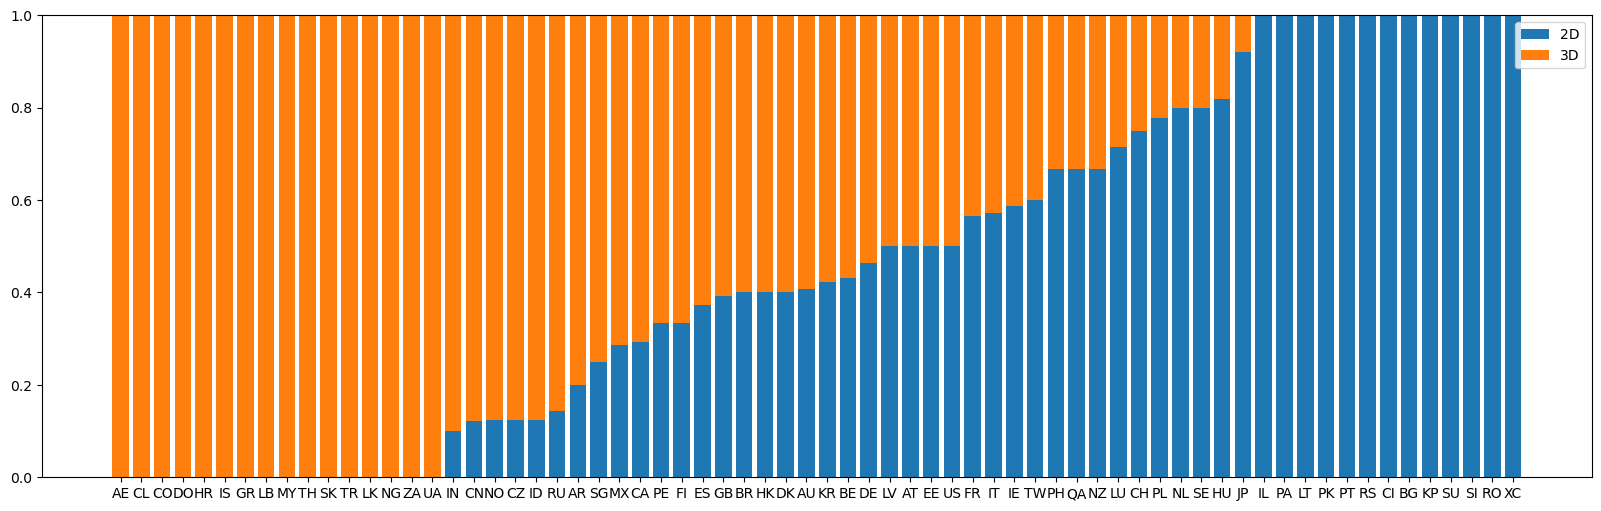

In [123]:
plt.figure(figsize=(20,6))
plt.bar(x=countries_portions.country, height=countries_portions.pct_2d, label='2D')
plt.bar(x=countries_portions.country, height=countries_portions.pct_3d, bottom=countries_portions.pct_2d, label='3D')
plt.legend()
plt.show()

In [169]:
# origin_countries_2d = pd.merge(tmdb_movies_2d.origin_country.str.split(',').explode().reset_index(), tmdb_movies_2d['id'], 
#          left_on='index', right_index=True)

In [170]:
# origin_countries_2d.drop(columns=['index'], inplace=True)

In [171]:
# origin_countries_2d.columns = ['origin_country', 'movie_id']

In [172]:
# origin_countries_2d.to_csv('Origin_Countries_2D.csv', index=False)

In [173]:
# origin_countries_3d = pd.merge(tmdb_movies_3d.origin_country.str.split(',').explode().reset_index(), tmdb_movies_3d['id'], 
         # left_on='index', right_index=True)

In [174]:
# origin_countries_3d.drop(columns=['index'], inplace=True)

In [175]:
# origin_countries_3d.columns = ['origin_country', 'movie_id']

In [176]:
# origin_countries_3d.to_csv('Origin_Countries_3D.csv', index=False)

In [177]:
# genres_2d = pd.merge(tmdb_movies_2d.genres_list.str.split(',').explode().reset_index(), tmdb_movies_2d['id'], 
#          left_on='index', right_index=True)

In [178]:
# genres_2d.drop(columns=['index'], inplace=True)
# genres_2d.columns = ['origin_country', 'movie_id']

In [179]:
# genres_2d.to_csv('Genres_2D.csv', index=False)

In [180]:
# genres_3d = pd.merge(tmdb_movies_3d.genres_list.str.split(',').explode().reset_index(), tmdb_movies_3d['id'], 
#          left_on='index', right_index=True)

In [181]:
# genres_3d.drop(columns=['index'], inplace=True)
# genres_3d.columns = ['origin_country', 'movie_id']

In [182]:
# genres_3d.to_csv('Genres_3D.csv', index=False)

In [188]:
genres_2d.columns = ['genre', 'movie_id']
genres_2d.to_csv('./data/Genres_2D.csv', index=False)

In [189]:
genres_3d.columns = ['genre', 'movie_id']
genres_3d.to_csv('./data/Genres_3D.csv', index=False)